In [2]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import fitsio as fio

In [11]:
tbl = fio.FITS('test_hsc_buzzard.fits')[1].read()
tbl2 = fio.FITS('../patch_hsc1/test_hsc_buzzard.fits')[1].read()

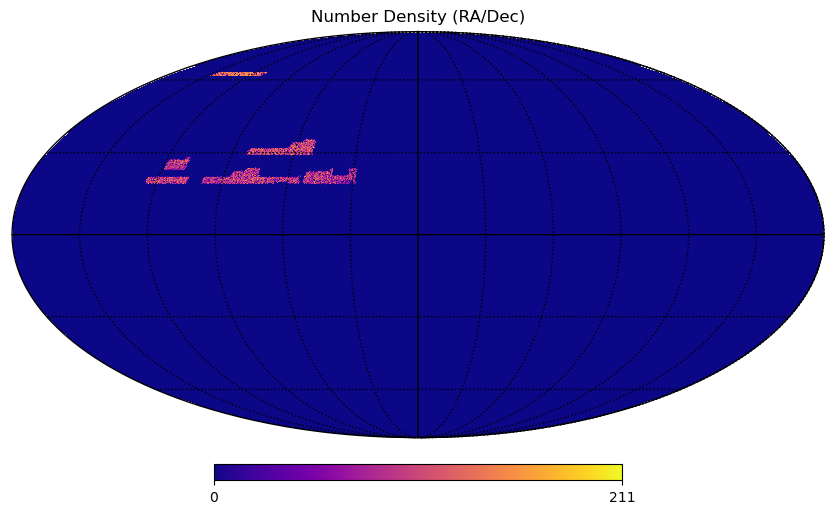

In [14]:
#ra = (tbl['RA']+260) % 360
#dec = tbl['DEC'] + 20
#ra2 = (tbl2['RA'] + 80) % 360
#dec2 = tbl2['DEC'] + 30

ra = (tbl['RA']+260*2) % 360
dec = (tbl['DEC']+20*2)
ra2 = (tbl2['RA'] + 80*2) % 360
dec2 = (tbl2['DEC'] + 30*2)

nside = 2048
theta = np.radians(90.0 - dec)
theta2 = np.radians(90.0 - dec2)
phi = np.radians(ra)       
phi2 = np.radians(ra2)    
pix = hp.ang2pix(nside, theta, phi, nest=True).astype(np.int64)
pix2 = hp.ang2pix(nside, theta2, phi2, nest=True).astype(np.int64)
# Create density map
npix = hp.nside2npix(nside)

density_map = np.bincount(pix, minlength=npix)
density_map2 = np.bincount(pix2, minlength=npix)
# sum the two maps
density_map += density_map2

# Plot the number density
hp.mollview(density_map, nest=True, cmap='plasma', title='Number Density (RA/Dec)')
hp.graticule()
plt.show()